# Gal4M Tutorial 0 — The dataset and its modalities

**Gal4M** adapts the [4M / AION](https://github.com/PolymathicAI/AION) "any-to-any"
multimodal-transformer recipe to *cosmological-simulation galaxies*. The goal of
the project is a single model that can take **any subset** of a galaxy's
properties and predict **any other subset** — e.g. the star-formation history and
dark-matter profile from just the face-on image, or the image from a few scalars.

We follow the 4M two-stage recipe:

1. **Codecs (Tutorial 1)** — tokenize every modality into a short sequence of
   *discrete integer tokens*, with a per-modality auto-encoder / quantizer.
2. **Transformer (Tutorial 2)** — train one masked multimodal transformer over
   the concatenated token streams.

![Tokenized multimodal learning](assets/Image-tokenized-multimodal-learning.png)

This first notebook simply **looks at the data**. We use the **redshift z = 0**
snapshot (`Snap99`) of IllustrisTNG **TNG-100**, concatenated into a single file,
so everything is small and fast. (Tutorials 1–2 then train on the full
multi-redshift set — five snapshots spanning z = 0.0 → 0.4.)

### The modalities we will model
| # | Modality | Array | Physical meaning |
|---|----------|-------|------------------|
| 1 | Galaxy face-on image | `star_faceon` `(8,128,128)` | 8-band stellar photometry, angular-momentum aligned |
| 2 | Star-formation history | `sfh` `(2,24)` | log SFR vs lookback time (0–12 Gyr) |
| 3 | Gas density profile | `gas_profile` `(2,20)` | log ρ_gas vs r/r200 |
| 4 | Dark-matter density profile | `dm_profile` `(2,20)` | log ρ_DM vs r/r200 |
| 5–8 | Scalars | `sfr, mstar, mhalo, r200` `(,)` | total SFR, stellar mass, halo mass, virial radius |

All quantities are already in physically sensible (mostly log) units. The full
pipeline in Tutorials 1–2 extends the scalar set to eight (adding black-hole mass,
two black-hole feedback channels, and redshift).

## Setup

We point Python at the local copy of the `aion` / `sim` source code that ships with the
tutorial, and load the concatenated z = 0 file **lazily** (`mmap_mode="r"`) so we never
pull the full ~1 GB into RAM — we only read the small slices we plot.

> **Data.** The z = 0 snapshot is pulled from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial) and downloads
> automatically on first use (into `data/`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))   # prefer the tutorial's local aion/ + sim/

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sim.hub import data_path
DATA_PATH = data_path("Snap99.npz")     # local data/, else downloaded from the HF Hub

data = np.load(DATA_PATH, mmap_mode="r")
N = data["mhalo"].shape[0]
print(f"z=0 galaxies: {N}\n")
for k in data.files:
    print(f"  {k:14s} {tuple(data[k].shape)}  {data[k].dtype}")

z=0 galaxies: 3878



  star_faceon    (3878, 8, 128, 128)  float16
  sfh            (3878, 2, 24)  float32
  gas_profile    (3878, 2, 20)  float32
  dm_profile     (3878, 2, 20)  float32
  scale_factor   (3878,)  float32
  r200           (3878,)  float32
  fofid          (3878,)  float32
  mstar          (3878,)  float32
  mhalo          (3878,)  float32
  sfr            (3878,)  float32
  mbh            (3878,)  float32
  egyRM          (3878,)  float32
  RMpow          (3878,)  float32


## A single galaxy, across all its modalities

The clearest way to understand the dataset is to take **one halo** and look at every
modality it carries. We pick a representative *star-forming, intermediate-mass* galaxy
so that its image, SFH and profiles all show structure.

In [2]:
mhalo_all = np.asarray(data["mhalo"])
mstar_all = np.asarray(data["mstar"])
sfr_all   = np.asarray(data["sfr"])

# Deterministically pick a star-forming, mid-mass galaxy for a nice "portrait".
mask = (sfr_all > -0.5) & (mstar_all > 10.5) & (mstar_all < 11.3)
cands = np.where(mask)[0]
HALO = int(cands[len(cands) // 2]) if len(cands) else 0
print(f"Selected halo index: {HALO}")

# Its scalar labels (modalities 5-8, all in log units).
print("\nScalar labels for this halo:")
print(f"  log10 SFR     = {float(data['sfr'][HALO]):.3f}   (M_sun/yr)")
print(f"  log10 M_star  = {float(data['mstar'][HALO]):.3f}   (M_sun, 35 ckpc/h aperture)")
print(f"  log10 M_halo  = {float(data['mhalo'][HALO]):.3f}   (M_sun, M_crit200)")
print(f"  log10 r200    = {float(data['r200'][HALO]):.3f}   (ckpc/h)")

Selected halo index: 1121

Scalar labels for this halo:
  log10 SFR     = -0.016   (M_sun/yr)
  log10 M_star  = 10.565   (M_sun, 35 ckpc/h aperture)
  log10 M_halo  = 12.251   (M_sun, M_crit200)
  log10 r200    = 2.238   (ckpc/h)


### Modality 1 — Galaxy face-on image (`star_faceon`)

Shape `(8, 128, 128)`: eight broad-band filters **U, B, V, K, g, r, i, z** (AB system)
in a 50 × 50 ckpc/h field of view, projected in the galaxy's **angular-momentum frame**
(so disks appear face-on). Stored as `log(1 + flux)`. Here are all 8 bands of our halo
(a per-image 1–99 percentile stretch is applied for *display* only).

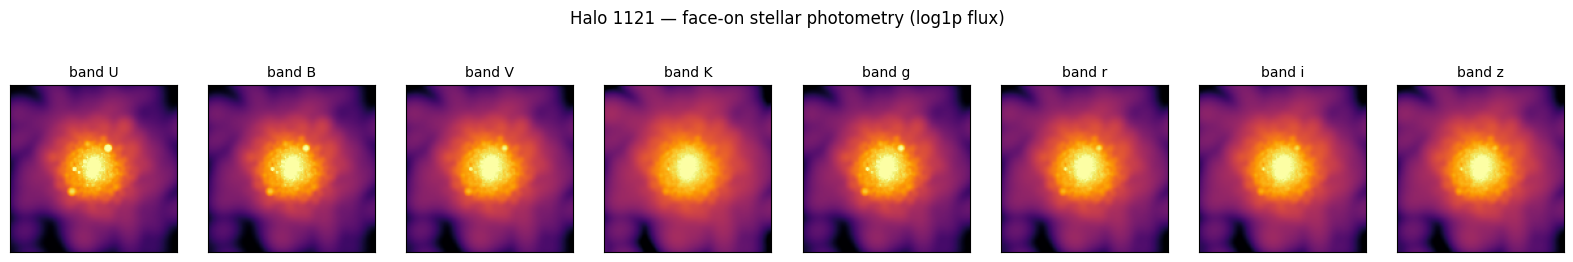

In [3]:
def stretch(im):
    lo, hi = np.percentile(im, 1), np.percentile(im, 99)
    return np.clip((im - lo) / max(hi - lo, 1e-6), 0, 1)

BAND_NAMES = ["U", "B", "V", "K", "g", "r", "i", "z"]
img = np.asarray(data["star_faceon"][HALO])   # (8, 128, 128)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.3))
for b, ax in enumerate(axes):
    ax.imshow(stretch(img[b]), cmap="inferno", origin="lower")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"band {BAND_NAMES[b]}", fontsize=10)
fig.suptitle(f"Halo {HALO} — face-on stellar photometry (log1p flux)", y=1.12)
fig.tight_layout(); plt.show()

### Modality 2 — Star-formation history (`sfh`)

Shape `(2, 24)`. Row 0 is a **fixed** lookback-time grid (24 bins, 0–12 Gyr, 0.5 Gyr
each); row 1 is `log10(SFR + 1e-6)` in each bin. The time grid is identical for every
galaxy, so the codec in Tutorial 1 only needs to encode the SFR row.

### Modalities 3 & 4 — Radial density profiles (`gas_profile`, `dm_profile`)

Shape `(2, 20)` each. Row 0 is normalized radius **r / r200** (fixed grid, 20 bins in
[0, 1]); row 1 is `log10(ρ)` in code units. The dark-matter profile is the classic
peaked-then-declining halo profile; the gas profile is shaped by cooling and feedback.

Below: the same halo's SFH and its two density profiles, side by side.

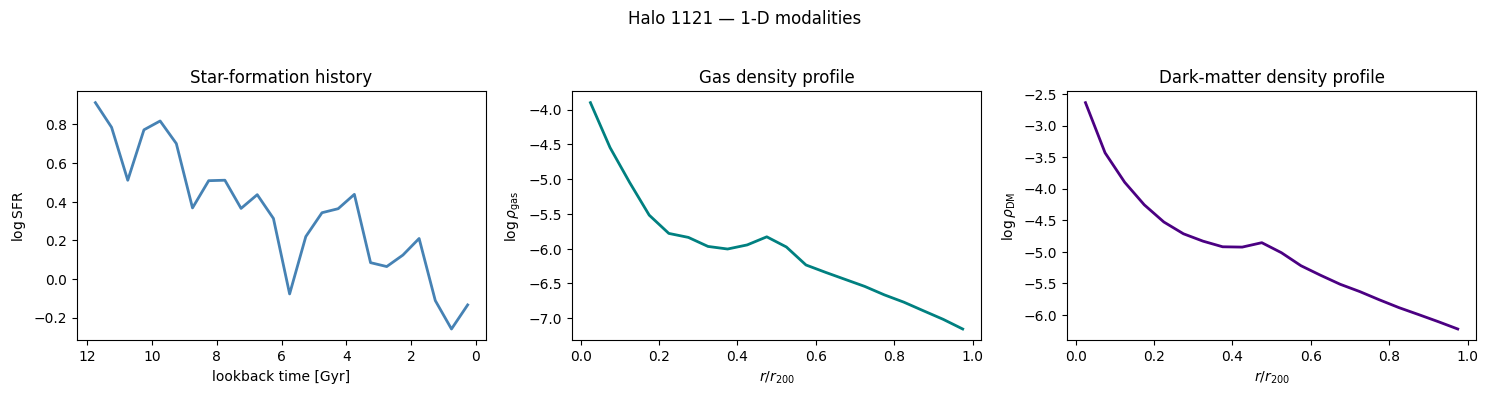

In [4]:
sfh = np.asarray(data["sfh"][HALO])              # (2, 24)
gp  = np.asarray(data["gas_profile"][HALO]).copy() # (2, 20)
dp  = np.asarray(data["dm_profile"][HALO]).copy()
gp[1] = np.clip(gp[1], -10, None)
dp[1] = np.clip(dp[1], -10, None)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
# SFH
ax[0].plot(sfh[0], sfh[1], color="steelblue", lw=2)
ax[0].invert_xaxis()   # present day on the right
ax[0].set_xlabel("lookback time [Gyr]"); ax[0].set_ylabel(r"$\log {\rm SFR}$")
ax[0].set_title("Star-formation history")
# gas profile
ax[1].plot(gp[0], gp[1], color="teal", lw=2)
ax[1].set_xlabel(r"$r / r_{200}$"); ax[1].set_ylabel(r"$\log \rho_{\rm gas}$")
ax[1].set_title("Gas density profile")
# DM profile
ax[2].plot(dp[0], dp[1], color="indigo", lw=2)
ax[2].set_xlabel(r"$r / r_{200}$"); ax[2].set_ylabel(r"$\log \rho_{\rm DM}$")
ax[2].set_title("Dark-matter density profile")
fig.suptitle(f"Halo {HALO} — 1-D modalities", y=1.03)
fig.tight_layout(); plt.show()

### Modalities 5–8 — Scalars

`sfr`, `mstar`, `mhalo`, `r200` are single numbers per galaxy (already in log scale) —
we printed them for this halo above. In Tutorial 1 each becomes a **single token** via a
cumulative-distribution-function quantizer.

That is the full multimodal "portrait" of one galaxy: an 8-band image, a 24-step
history, two 20-step profiles, and four scalars. The transformer learns the joint
distribution of all of these across the population.

## The galaxy population

Finally, a look at the population these halos are drawn from: the **massive** end of
TNG-100 (log M_halo/M_⊙ ≳ 11), spanning group to cluster scales. Below are the 1-D
distributions of the three headline scalars.

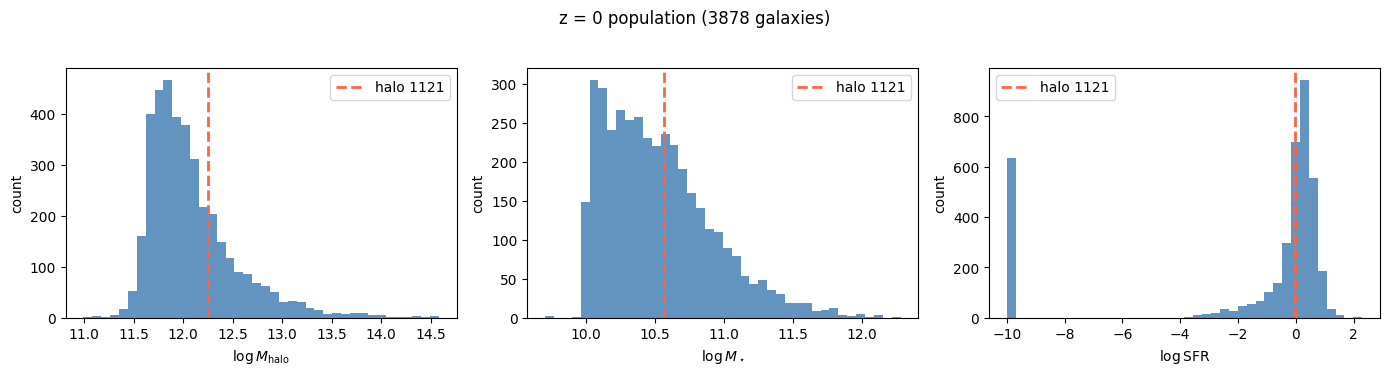

Quenched fraction (log SFR at floor): 16.4%


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, (v, lab) in zip(ax, [(mhalo_all, r"$\log M_{\rm halo}$"),
                            (mstar_all, r"$\log M_\star$"),
                            (sfr_all,   r"$\log {\rm SFR}$")]):
    a.hist(v, bins=40, color="steelblue", alpha=0.85)
    a.axvline(float(v[HALO]), color="tomato", lw=2, ls="--", label=f"halo {HALO}")
    a.set_xlabel(lab); a.set_ylabel("count"); a.legend()
fig.suptitle(f"z = 0 population ({N} galaxies)", y=1.03)
fig.tight_layout(); plt.show()

print(f"Quenched fraction (log SFR at floor): {float((sfr_all <= -5).mean()):.1%}")

## Recap: from modalities to tokens

Tutorial 1 turns each modality into discrete tokens with a per-modality codec:

| Modality | Token key | # tokens | codec vocab | Codec family |
|----------|-----------|---------:|------:|--------------|
| galaxy face-on image | `tok_sim_galaxy_image` | 1024 | 625 | 2-D MagVit VQ-AE + FSQ |
| star-formation history | `tok_sim_sfh` | 6 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| gas density profile | `tok_sim_gas_profile` | 5 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| DM density profile | `tok_sim_dm_profile` | 5 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| scalars (sfr, mstar, …) | `tok_sim_*` | 1 each | 1024 | scalar quantile quantizer |

➡️ Continue with **`tutorial-1-codecs.ipynb`**.